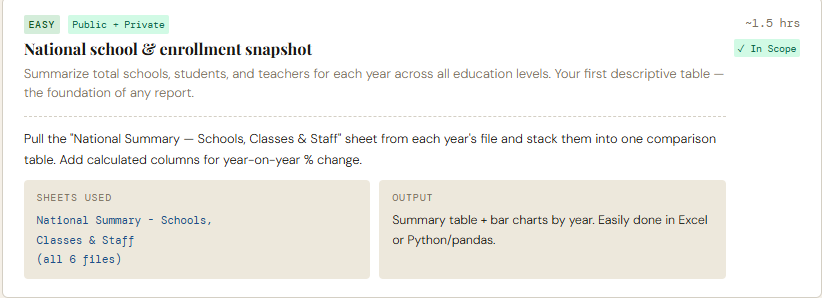

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# To read the second sheet (index 1)
private_18_19 = pd.read_excel('organized_education_data/private_schools_2018-2019.xlsx', sheet_name="National Summary - Schools, Cla")
private_19_20 = pd.read_excel('organized_education_data/private_schools_2019-2020.xlsx', sheet_name="National Summary - Schools, Cla")
private_20_21 = pd.read_excel('organized_education_data/private_schools_2020-2021.xlsx', sheet_name="National Summary - Schools, Cla")
public_18_19 = pd.read_excel('organized_education_data/public_schools_2018-2019.xlsx', sheet_name="National Summary - Schools, Cla")
public_19_20 = pd.read_excel('organized_education_data/public_schools_2019-2020.xlsx', sheet_name="National Summary - Schools, Cla")
public_20_21 = pd.read_excel('organized_education_data/public_schools_2020-2021.xlsx', sheet_name="National Summary - Schools, Cla")

In [ ]:
private_18_19

,"Table 1: Schools, Classes, Students and Staff",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Particulars,Number of Schools,Number of Classes,Schools,NaN,NaN,NaN,NaN,NaN,NaN,Enrollment,NaN,Repeaters,NaN,Teaching Staff,NaN,Non-Teaching Staff,NaN,Govern. staff,Foreigner Teaching Staff
1,NaN,NaN,NaN,Khmer,Chinesse,Muslim,French,English,Vietnamese,Other,Total,Girl,Total,Girl,Total,Female,Total,Female,NaN,NaN
2,Whole Kingdom,1222,8990,975,55,28,1,160,1,2,218357,108580,2986,1183,13496,8143,5318,3034,5069,1792
3,Pre School,509,2051,373,19,5,1,110,0,1,48318,23849,0,0,2740,2338,1474,954,271,594
4,Primary School,488,5047,406,26,17,0,37,1,1,122886,61136,2425,989,5742,3887,2384,1360,1593,711
5,College (Grade7-9),78,216,62,10,1,0,5,0,0,4017,2067,6,3,687,305,255,156,392,202
6,Lycee (Grade10-12),2,6,2,0,0,0,0,0,0,238,146,0,0,35,10,7,3,33,1
7,Lycee (Grade7-12),145,1670,132,0,5,0,8,0,0,42898,21382,555,191,4292,1603,1198,561,2780,284
8,Lower Secondary (Grade7-9),223,1125,194,10,6,0,13,0,0,28451,14139,330,98,NaN,NaN,NaN,NaN,NaN,NaN
9,Upper Secondary (Grade10-12),147,767,134,0,5,0,8,0,0,18702,9456,231,96,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def clean_up(df):
    row = df.iloc[0]
    df = df.rename(columns=row)
    df = df.drop(columns=[col for col in df.columns if pd.isna(col)])
    df = df.iloc[2:]
    df = df.reset_index(drop=True)
    df = df.drop(columns=["Schools"])
    df = df.set_index("Particulars")
    df = df.astype('Int64')
    return df

In [ ]:
def clean_up_for_pub(df):
    df = df.iloc[1:]
    row = df.iloc[0]
    df = df.rename(columns=row)
    df = df.drop(columns=[col for col in df.columns if pd.isna(col)])
    df = df.iloc[2:]
    df = df.reset_index(drop=True)
    df = df.set_index("Particulars")
    df = df.astype('Int64')
    return df

In [ ]:
private_18_19 = clean_up(private_18_19)
private_19_20 = clean_up(private_19_20)
private_20_21 = clean_up(private_20_21)
public_18_19 = clean_up_for_pub(public_18_19)
public_19_20 = clean_up_for_pub(public_19_20)
public_20_21 = clean_up_for_pub(public_20_21)

In [ ]:
private_18_19.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Whole Kingdom to - Rural Area
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Number of Schools         10 non-null     Int64
 1   Number of Classes         10 non-null     Int64
 2   Enrollment                10 non-null     Int64
 3   Repeaters                 10 non-null     Int64
 4   Teaching Staff            8 non-null      Int64
 5   Non-Teaching Staff        8 non-null      Int64
 6   Govern. staff             8 non-null      Int64
 7   Foreigner Teaching Staff  8 non-null      Int64
dtypes: Int64(8)
memory usage: 800.0+ bytes


      Year  Public  Private
0  2018-19   13300     1222
1  2019-20   13482     1426
2  2020-21   13681     1666


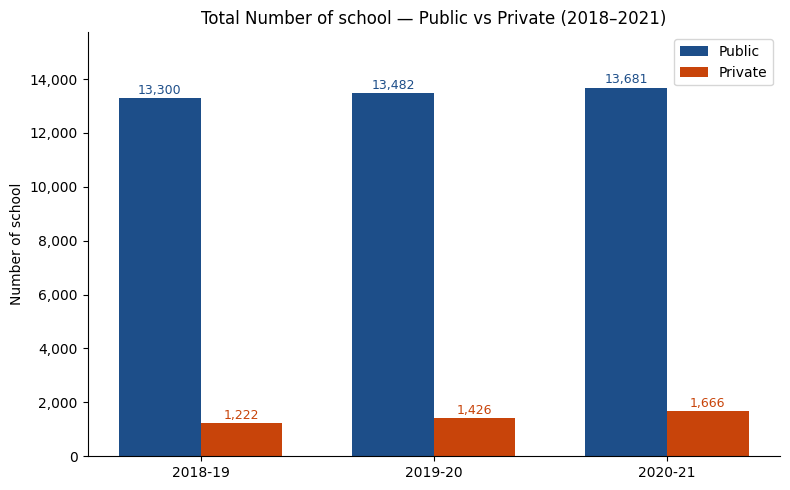

In [ ]:
def get_total_schools_private(df):
    return int(df.loc["Whole Kingdom", "Number of Schools"])

def get_total_schools_public(df):
    return int(df.loc["Whole Kingdom"].iloc[0])

data = {
    "Year":   ["2018-19", "2019-20", "2020-21"],
    "Public": [
        get_total_schools_public(public_18_19),
        get_total_schools_public(public_19_20),
        get_total_schools_public(public_20_21),
    ],
    "Private": [
        get_total_schools_private(private_18_19),
        get_total_schools_private(private_19_20),
        get_total_schools_private(private_20_21),
    ],
}

df_plot = pd.DataFrame(data)
print(df_plot)  # check the numbers first

# ── Step 2: Plot ─────────────────────────────────────────────────────────────

x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_pub = ax.bar([i - width/2 for i in x], df_plot["Public"],  width, label="Public",  color="#1d4e89")
bars_pri = ax.bar([i + width/2 for i in x], df_plot["Private"], width, label="Private", color="#c8440a")

# Add value labels on top of each bar
for bar in bars_pub:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#1d4e89")
for bar in bars_pri:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#c8440a")

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["Year"])
ax.set_ylabel("Number of school")
ax.set_title("Total Number of school — Public vs Private (2018–2021)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylim(0, df_plot[["Public","Private"]].values.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

      Year  Public  Private
0  2018-19   89897     8990
1  2019-20   91259    11000
2  2020-21   95909    11895


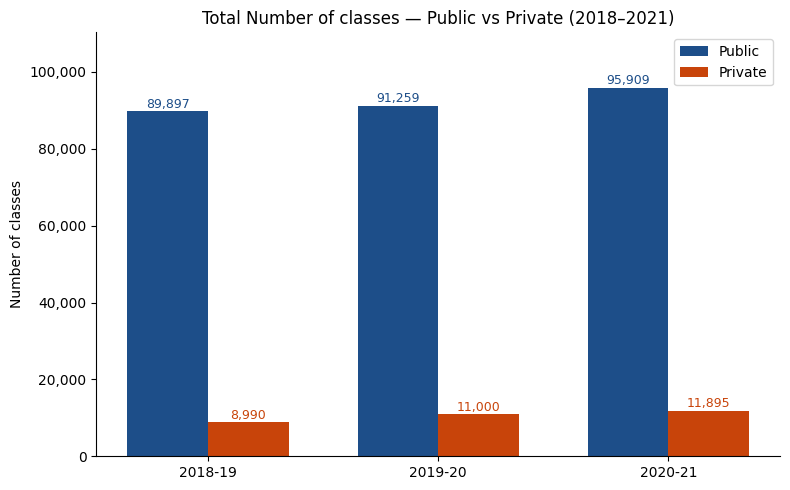

In [ ]:
def get_total_Class_private(df):
    return int(df.loc["Whole Kingdom", "Number of Classes"])

def get_total_Class_public(df):
    return int(df.loc["Whole Kingdom"].iloc[2])

data = {
    "Year":   ["2018-19", "2019-20", "2020-21"],
    "Public": [
        get_total_Class_public(public_18_19),
        get_total_Class_public(public_19_20),
        get_total_Class_public(public_20_21),
    ],
    "Private": [
        get_total_Class_private(private_18_19),
        get_total_Class_private(private_19_20),
        get_total_Class_private(private_20_21),
    ],
}

df_plot = pd.DataFrame(data)
print(df_plot)
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_pub = ax.bar([i - width/2 for i in x], df_plot["Public"],  width, label="Public",  color="#1d4e89")
bars_pri = ax.bar([i + width/2 for i in x], df_plot["Private"], width, label="Private", color="#c8440a")

for bar in bars_pub:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#1d4e89")
for bar in bars_pri:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#c8440a")

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["Year"])
ax.set_ylabel("Number of classes")
ax.set_title("Total Number of classes — Public vs Private (2018–2021)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylim(0, df_plot[["Public","Private"]].values.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

      Year   Public  Private
0  2018-19  3189172   218357
1  2019-20  3210285   253569
2  2020-21  3277076   240550


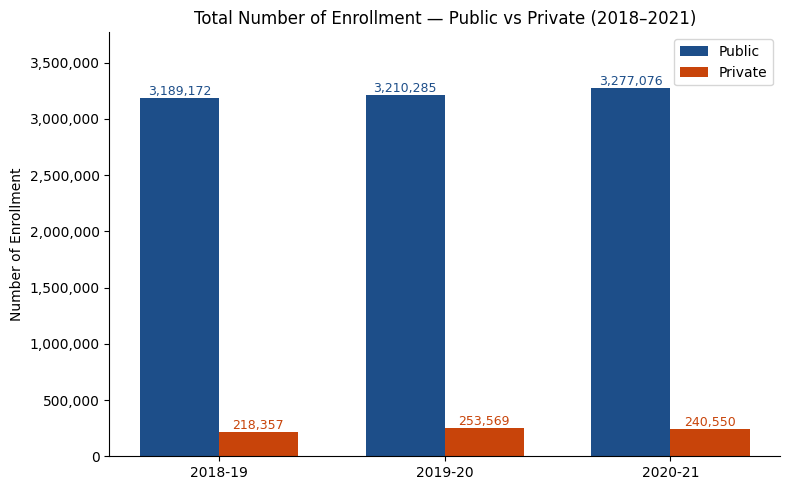

In [ ]:
def get_total_Enrollment_private(df):
    return int(df.loc["Whole Kingdom", "Enrollment"])

def get_total_Enrollment_public(df):
    return int(df.loc["Whole Kingdom"].iloc[1])

data = {
    "Year":   ["2018-19", "2019-20", "2020-21"],
    "Public": [
        get_total_Enrollment_private(public_18_19),
        get_total_Enrollment_private(public_19_20),
        get_total_Enrollment_private(public_20_21),
    ],
    "Private": [
        get_total_Enrollment_private(private_18_19),
        get_total_Enrollment_private(private_19_20),
        get_total_Enrollment_private(private_20_21),
    ],
}

df_plot = pd.DataFrame(data)
print(df_plot)
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_pub = ax.bar([i - width/2 for i in x], df_plot["Public"],  width, label="Public",  color="#1d4e89")
bars_pri = ax.bar([i + width/2 for i in x], df_plot["Private"], width, label="Private", color="#c8440a")

for bar in bars_pub:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#1d4e89")
for bar in bars_pri:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#c8440a")

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["Year"])
ax.set_ylabel("Number of Enrollment")
ax.set_title("Total Number of Enrollment — Public vs Private (2018–2021)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylim(0, df_plot[["Public","Private"]].values.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

      Year  Public  Private
0  2018-19  148021     2986
1  2019-20  150757     3799
2  2020-21  175718     2832


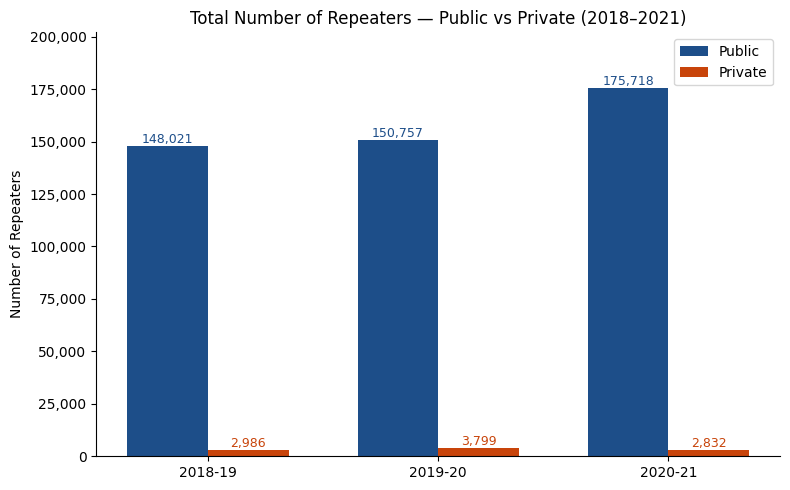

In [ ]:
def get_total_Repeaters_private(df):
    return int(df.loc["Whole Kingdom", "Repeaters"])

def get_total_Repeaters_public(df):
    return int(df.loc["Whole Kingdom"].iloc[5])

data = {
    "Year":   ["2018-19", "2019-20", "2020-21"],
    "Public": [
        get_total_Repeaters_public(public_18_19),
        get_total_Repeaters_public(public_19_20),
        get_total_Repeaters_public(public_20_21),
    ],
    "Private": [
        get_total_Repeaters_private(private_18_19),
        get_total_Repeaters_private(private_19_20),
        get_total_Repeaters_private(private_20_21),
    ],
}

df_plot = pd.DataFrame(data)
print(df_plot)
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_pub = ax.bar([i - width/2 for i in x], df_plot["Public"],  width, label="Public",  color="#1d4e89")
bars_pri = ax.bar([i + width/2 for i in x], df_plot["Private"], width, label="Private", color="#c8440a")
for bar in bars_pub:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#1d4e89")
for bar in bars_pri:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#c8440a")

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["Year"])
ax.set_ylabel("Number of Repeaters")
ax.set_title("Total Number of Repeaters — Public vs Private (2018–2021)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylim(0, df_plot[["Public","Private"]].values.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

      Year  Public  Private
0  2018-19  112769    18814
1  2019-20  113087    23345
2  2020-21  115549    22182


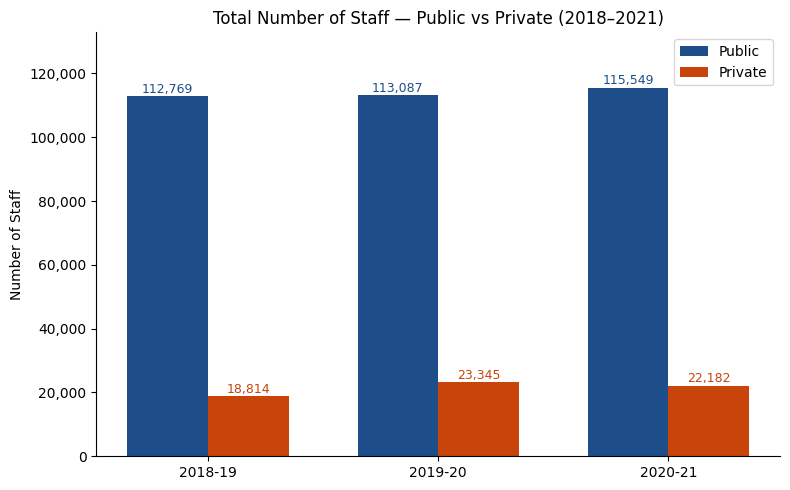

In [ ]:
def get_total_Repeaters_private(df):
    return int(df.loc["Whole Kingdom", "Teaching Staff"])+int(df.loc["Whole Kingdom", "Non-Teaching Staff"])

def get_total_Repeaters_public(df):
    return int(df.loc["Whole Kingdom"].iloc[8])

data = {
    "Year":   ["2018-19", "2019-20", "2020-21"],
    "Public": [
        get_total_Repeaters_public(public_18_19),
        get_total_Repeaters_public(public_19_20),
        get_total_Repeaters_public(public_20_21),
    ],
    "Private": [
        get_total_Repeaters_private(private_18_19),
        get_total_Repeaters_private(private_19_20),
        get_total_Repeaters_private(private_20_21),
    ],
}

df_plot = pd.DataFrame(data)
print(df_plot)
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_pub = ax.bar([i - width/2 for i in x], df_plot["Public"],  width, label="Public",  color="#1d4e89")
bars_pri = ax.bar([i + width/2 for i in x], df_plot["Private"], width, label="Private", color="#c8440a")

for bar in bars_pub:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#1d4e89")
for bar in bars_pri:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, color="#c8440a")

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["Year"])
ax.set_ylabel("Number of Staff")
ax.set_title("Total Number of Staff — Public vs Private (2018–2021)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylim(0, df_plot[["Public","Private"]].values.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Sivting 
print("I love you")



I love you
